Mounted at /content/drive
Loading Raw Merged Data: /content/drive/MyDrive/EarthEngine_ML_Data/raw_merged_dataset.csv

Using DSWE column: DSWE_mean
--- Label distribution ---
Y
0    1080
1     480
Name: count, dtype: int64
Positive rate: 0.3076923076923077

Sequence dataset: (1365, 14, 7) (1365,)
Seq positive rate: 0.3054945054945055

--- Split sizes ---
Train: (735, 14, 7) Test: (630, 14, 7)
Train pos rate: 0.23945578231292516 Test pos rate: 0.3825396825396825

Class weights (capped): {0: 1.0, 1: 3.1761363636363638}
Epoch 1/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 133ms/step - loss: 1.0984 - pr_auc: 0.2775 - roc_auc: 0.5010 - val_loss: 0.7051 - val_pr_auc: 0.3772 - val_roc_auc: 0.5954 - learning_rate: 0.0010
Epoch 2/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 1.0684 - pr_auc: 0.3743 - roc_auc: 0.6117 - val_loss: 0.6843 - val_pr_auc: 0.3166 - val_roc_auc: 0.6238 - learning_rate: 0.0010
Epoch 3/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 1.0640 - pr_auc: 0.3722 - roc_auc: 0.6262 - val_lo

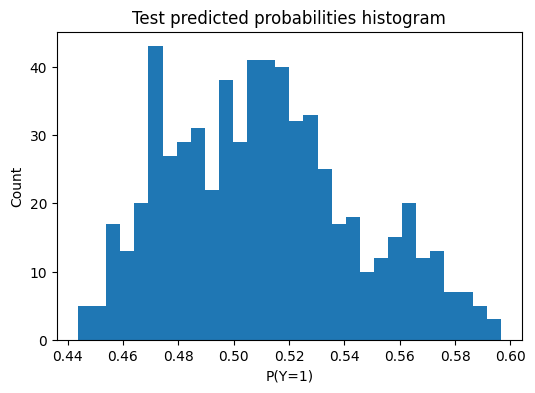


--- Threshold sweep (TEST) ---
thr=0.05  pred_pos= 630  precision=0.383  recall=1.000  f1=0.553
thr=0.10  pred_pos= 630  precision=0.383  recall=1.000  f1=0.553
thr=0.15  pred_pos= 630  precision=0.383  recall=1.000  f1=0.553
thr=0.20  pred_pos= 630  precision=0.383  recall=1.000  f1=0.553
thr=0.30  pred_pos= 630  precision=0.383  recall=1.000  f1=0.553
thr=0.40  pred_pos= 630  precision=0.383  recall=1.000  f1=0.553
thr=0.50  pred_pos= 379  precision=0.515  recall=0.809  f1=0.629

Best TEST threshold by F1 (debug only): {'thr': 0.49999999999999994, 'pred_pos': 379, 'precision': np.float64(0.5145118733509235), 'recall': np.float64(0.8091286307053942), 'f1': 0.6290322580645161}

--- Test report @ thr=0.50 ---
              precision    recall  f1-score   support

           0     0.8167    0.5270    0.6406       389
           1     0.5145    0.8091    0.6290       241

    accuracy                         0.6349       630
   macro avg     0.6656    0.6681    0.6348       630
weighted 

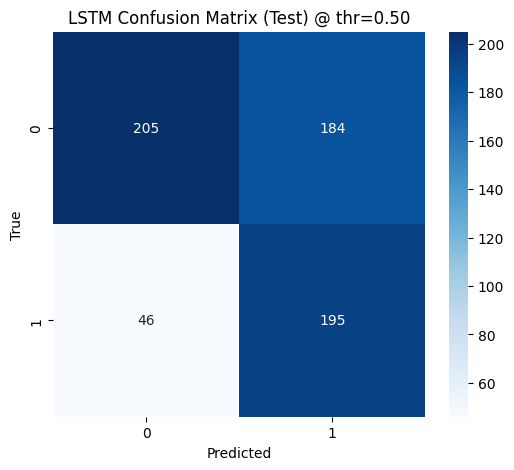

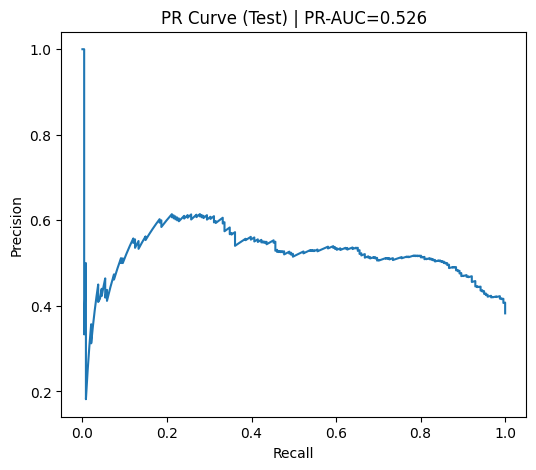


Saved predictions to: /content/drive/MyDrive/EarthEngine_ML_Data/lstm_outputs_raw/lstm_raw_dsweLabel_ratio1.09_seq14_split2019.csv
Saved model to: /content/drive/MyDrive/EarthEngine_ML_Data/lstm_outputs_raw/lstm_raw_dsweLabel_ratio1.09_seq14_split2019.keras


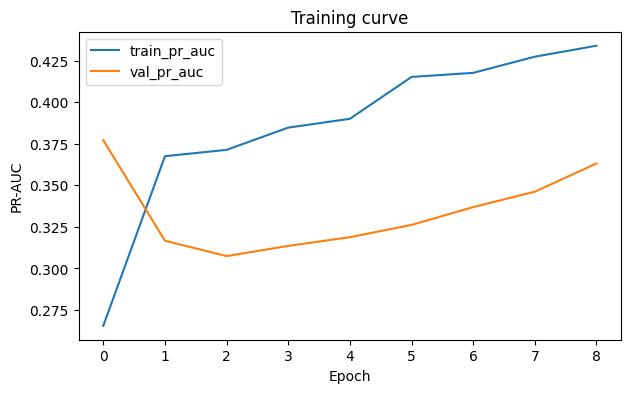

In [ ]:
# ============================================================
# LSTM (time spilt) — Train on raw_merged_dataset.csv

# Label: DSWE-baseline rule
#   Is_Flood = 1 if DSWE > median(DSWE per Region_ID) * RATIO
#
# Task: SAME-DAY mapping (no shift / no next observation)
# Features: rainfall windows + seasonality
# Split: train < 2019, test >= 2019
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

from sklearn.metrics import (
    classification_report, confusion_matrix,
    average_precision_score, precision_recall_curve, f1_score
)

# -----------------------------
# 1) SETUP
# -----------------------------
drive.mount('/content/drive')
BASE_DIR   = "/content/drive/MyDrive/EarthEngine_ML_Data"
INPUT_FILE = os.path.join(BASE_DIR, "raw_merged_dataset.csv")
OUT_DIR    = os.path.join(BASE_DIR, "lstm_outputs_raw")
os.makedirs(OUT_DIR, exist_ok=True)

# uploaded file
LOCAL_FALLBACK = "/mnt/data/raw_merged_dataset.csv"
if not os.path.exists(INPUT_FILE) and os.path.exists(LOCAL_FALLBACK):
    INPUT_FILE = LOCAL_FALLBACK

print(f"Loading Raw Merged Data: {INPUT_FILE}")
df = pd.read_csv(INPUT_FILE)

# -----------------------------
# 2) Basic cleanup + sorting
# -----------------------------
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.dropna(subset=["Date"]).copy()

if "Region_ID" not in df.columns:
    raise ValueError("raw_merged_dataset.csv must have a 'Region_ID' column.")

df = df.sort_values(["Region_ID", "Date"]).reset_index(drop=True)


# -----------------------------
# 3) create label
# -----------------------------
DSWE_CANDIDATES = ["DSWE_mean"]


DSWE_COL = None
for c in DSWE_CANDIDATES:
    if c in df.columns:
        DSWE_COL = c
        break

if DSWE_COL is None:
    # helpful debugging: print likely columns
    print("\nColumns found:")
    print(df.columns.tolist())
    raise ValueError(
        f"Could not find a DSWE column. Tried: {DSWE_CANDIDATES}. "
        "Please tell me the DSWE column name in raw_merged_dataset.csv."
    )

df[DSWE_COL] = pd.to_numeric(df[DSWE_COL], errors="coerce")
df = df.dropna(subset=[DSWE_COL]).copy()

RATIO = 1.09
df["Baseline_DSWE"] = df.groupby("Region_ID")[DSWE_COL].transform("median")
df["Is_Flood"] = (df[DSWE_COL] > (df["Baseline_DSWE"] * RATIO)).astype(int)

# Final target
df["Y"] = df["Is_Flood"].astype(int)

print(f"\nUsing DSWE column: {DSWE_COL}")
print("--- Label distribution ---")
print(df["Y"].value_counts().sort_index())
print("Positive rate:", df["Y"].mean())

# -----------------------------
# 4) Features
# -----------------------------
FEATURES = [
    "Precip_mm",
    "rain_sum_7", "rain_sum_15", "rain_sum_30",
    "rain_sum_60", "rain_sum_90",
    "rain_days_7",
]
FEATURES = [c for c in FEATURES if c in df.columns]
if len(FEATURES) == 0:
    print("\nColumns found:")
    print(df.columns.tolist())
    raise ValueError("No rainfall features found. Check raw_merged_dataset.csv column names.")

X_raw = df[FEATURES].apply(pd.to_numeric, errors="coerce")
mask = X_raw.notna().all(axis=1) & df["Y"].notna()
df = df.loc[mask].copy()
X_raw = X_raw.loc[mask].copy()
y_raw = df["Y"].astype(int)

# -----------------------------
# 5) Build sequences per Region_ID
# -----------------------------
SEQ_LEN = 14   # try 7, 14, 30

def build_sequences(df_in: pd.DataFrame, X_in: pd.DataFrame, y_in: pd.Series, seq_len: int):
    X_list, y_list, meta_list = [], [], []
    for rid, idxs in df_in.groupby("Region_ID").indices.items():
        idxs = np.array(sorted(idxs))
        if len(idxs) < seq_len:
            continue
        for j in range(seq_len - 1, len(idxs)):
            win = idxs[j - seq_len + 1 : j + 1]
            X_seq = X_in.iloc[win].values.astype(np.float32)
            y_val = int(y_in.iloc[idxs[j]])
            meta = df_in.iloc[idxs[j]][["Region_ID", "Date"]].to_dict()
            meta["Y"] = y_val
            X_list.append(X_seq)
            y_list.append(y_val)
            meta_list.append(meta)

    X_out = np.stack(X_list, axis=0) if X_list else np.empty((0, seq_len, X_in.shape[1]), dtype=np.float32)
    y_out = np.array(y_list, dtype=np.int32)
    meta_out = pd.DataFrame(meta_list)
    return X_out, y_out, meta_out

df = df.sort_values(["Region_ID", "Date"]).reset_index(drop=True)
X_seq_all, y_all, meta_all = build_sequences(df, X_raw, y_raw, SEQ_LEN)

print("\nSequence dataset:", X_seq_all.shape, y_all.shape)
if len(y_all) == 0:
    raise ValueError("No sequences created. Lower SEQ_LEN or check Region_ID time series length.")
print("Seq positive rate:", y_all.mean())

# -----------------------------
# 6) Time split
# -----------------------------
split_year = 2019
meta_all["Date"] = pd.to_datetime(meta_all["Date"])
train_mask = meta_all["Date"].dt.year < split_year
test_mask  = meta_all["Date"].dt.year >= split_year

X_train = X_seq_all[train_mask.values]
y_train = y_all[train_mask.values]
X_test  = X_seq_all[test_mask.values]
y_test  = y_all[test_mask.values]
meta_test = meta_all.loc[test_mask].reset_index(drop=True)

print("\n--- Split sizes ---")
print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train pos rate:", y_train.mean(), "Test pos rate:", y_test.mean())

# -----------------------------
# 7) Standardize using TRAIN only
# -----------------------------
eps = 1e-6
mu = X_train.reshape(-1, X_train.shape[-1]).mean(axis=0)
sd = X_train.reshape(-1, X_train.shape[-1]).std(axis=0) + eps

def standardize(X, mu, sd):
    return (X - mu.reshape(1,1,-1)) / sd.reshape(1,1,-1)

X_train_s = standardize(X_train, mu, sd)
X_test_s  = standardize(X_test,  mu, sd)

# -----------------------------
# 8) LSTM model
# -----------------------------
tf.keras.utils.set_random_seed(42)

model = models.Sequential([
    layers.Input(shape=(SEQ_LEN, X_train_s.shape[-1])),
    layers.LSTM(64),
    layers.Dropout(0.25),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.20),
    layers.Dense(1, activation="sigmoid"),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.AUC(curve="PR", name="pr_auc"),
        tf.keras.metrics.AUC(curve="ROC", name="roc_auc")
    ]
)

# Capped class weights
pos = int((y_train == 1).sum())
neg = int((y_train == 0).sum())
raw_w1 = neg / max(pos, 1)
w1 = float(min(raw_w1, 10.0))
class_weight = {0: 1.0, 1: w1}
print("\nClass weights (capped):", class_weight)

cb = [
    callbacks.EarlyStopping(monitor="val_pr_auc", mode="max", patience=8, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_pr_auc", mode="max", factor=0.5, patience=4, min_lr=1e-5),
]

history = model.fit(
    X_train_s, y_train,
    validation_split=0.2,
    epochs=60,
    batch_size=128,
    class_weight=class_weight,
    callbacks=cb,
    verbose=1
)

# -----------------------------
# 9) Evaluate
# -----------------------------
proba_test = model.predict(X_test_s, batch_size=256).ravel()

pr_auc = average_precision_score(y_test, proba_test)
base = float(np.mean(y_test))
print("\n--- Test ranking metric ---")
print(f"PR-AUC: {pr_auc:.4f} | Base rate: {base:.4f}")

# diagnostics
print("proba_test quantiles:", np.quantile(proba_test, [0,0.05,0.25,0.5,0.75,0.95,1.0]))
plt.figure(figsize=(6,4))
plt.hist(proba_test, bins=30)
plt.title("Test predicted probabilities histogram")
plt.xlabel("P(Y=1)")
plt.ylabel("Count")
plt.show()

def eval_at_threshold(t):
    pred = (proba_test >= t).astype(int)
    cm = confusion_matrix(y_test, pred)
    tp = cm[1,1]; fp = cm[0,1]; fn = cm[1,0]
    prec = tp/(tp+fp) if (tp+fp)>0 else 0.0
    rec  = tp/(tp+fn) if (tp+fn)>0 else 0.0
    f1   = f1_score(y_test, pred, zero_division=0)
    return {"thr": t, "pred_pos": int(pred.sum()), "precision": prec, "recall": rec, "f1": f1}

print("\n--- Threshold sweep (TEST) ---")
for t in [0.05,0.10,0.15,0.20,0.30,0.40,0.50]:
    r = eval_at_threshold(t)
    print(f"thr={r['thr']:.2f}  pred_pos={r['pred_pos']:4d}  precision={r['precision']:.3f}  recall={r['recall']:.3f}  f1={r['f1']:.3f}")

ths = np.linspace(0.05, 0.95, 19)
best = None
for t in ths:
    r = eval_at_threshold(float(t))
    if best is None or r["f1"] > best["f1"]:
        best = r
print("\nBest TEST threshold by F1 (debug only):", best)

t_use = float(best["thr"])
pred_test = (proba_test >= t_use).astype(int)

print(f"\n--- Test report @ thr={t_use:.2f} ---")
print(classification_report(y_test, pred_test, digits=4, zero_division=0))

cm = confusion_matrix(y_test, pred_test)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["0","1"], yticklabels=["0","1"])
plt.title(f"LSTM Confusion Matrix (Test) @ thr={t_use:.2f}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

prec, rec, _ = precision_recall_curve(y_test, proba_test)
plt.figure(figsize=(6,5))
plt.plot(rec, prec)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"PR Curve (Test) | PR-AUC={pr_auc:.3f}")
plt.show()

# -----------------------------
# 10) Save outputs
# -----------------------------
pred_df = meta_test.copy()
pred_df["P_y1"] = proba_test
pred_df["Pred_y1"] = pred_test

pred_path = os.path.join(OUT_DIR, f"lstm_raw_dsweLabel_ratio{RATIO}_seq{SEQ_LEN}_split{split_year}.csv")
pred_df.to_csv(pred_path, index=False)
print("\nSaved predictions to:", pred_path)

model_path = os.path.join(OUT_DIR, f"lstm_raw_dsweLabel_ratio{RATIO}_seq{SEQ_LEN}_split{split_year}.keras")
model.save(model_path)

np.save(os.path.join(OUT_DIR, f"scaler_mu_seq{SEQ_LEN}.npy"), mu)
np.save(os.path.join(OUT_DIR, f"scaler_sd_seq{SEQ_LEN}.npy"), sd)
print("Saved model to:", model_path)

plt.figure(figsize=(7,4))
plt.plot(history.history.get("pr_auc", []), label="train_pr_auc")
plt.plot(history.history.get("val_pr_auc", []), label="val_pr_auc")
plt.xlabel("Epoch")
plt.ylabel("PR-AUC")
plt.title("Training curve")
plt.legend()
plt.show()


Mounted at /content/drive
Loading: /content/drive/MyDrive/EarthEngine_ML_Data/raw_merged_dataset.csv

--- Label distribution ---
Y
0    1080
1     480
Name: count, dtype: int64
Positive rate: 0.3076923076923077
Share Baseline_DSWE==0: 0.8666666666666667

After dropna: (1560, 10)
Date range: 2015-01-26 00:00:00 to 2021-12-21 00:00:00

Sequence dataset: (1365, 14, 7) (1365,)
Seq positive rate: 0.3054945054945055

--- Split sizes (random) ---
Train: (819, 14, 7) Val: (273, 14, 7) Test: (273, 14, 7)
Train pos rate: 0.3052503052503053 Val pos rate: 0.3076923076923077 Test pos rate: 0.304029304029304

Class weights (capped): {0: 1.0, 1: 2.276}
Epoch 1/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 143ms/step - loss: 0.9582 - pr_auc: 0.3317 - roc_auc: 0.5592 - val_loss: 0.6724 - val_pr_auc: 0.4300 - val_roc_auc: 0.6411 - learning_rate: 0.0010
Epoch 2/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.9252 - pr_auc: 0.4069 - roc_auc: 0.6473 - val_loss: 0.6565 - val_pr_auc: 0.4343 - val_roc_auc: 0.6749 - learn

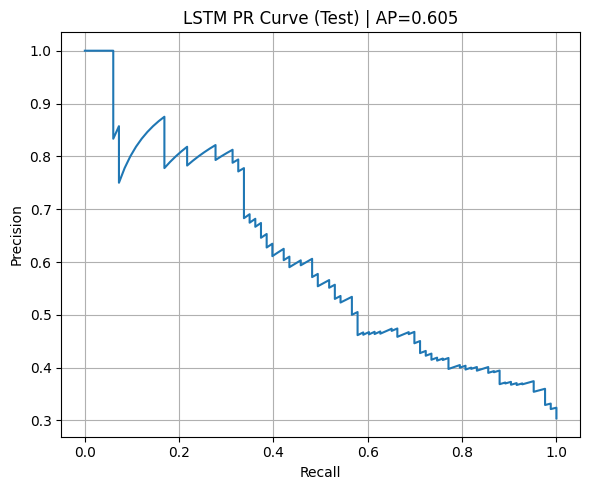

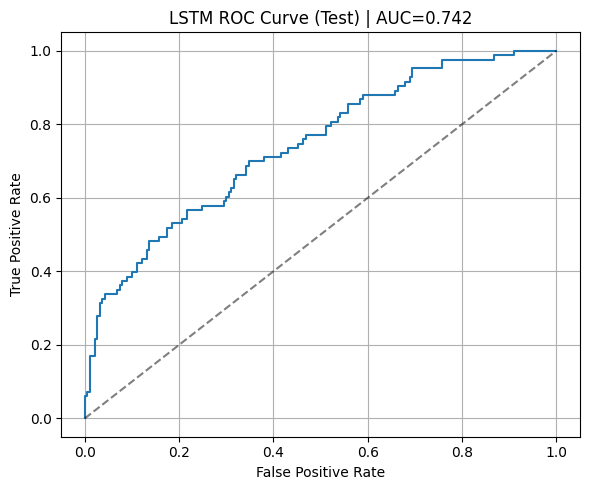

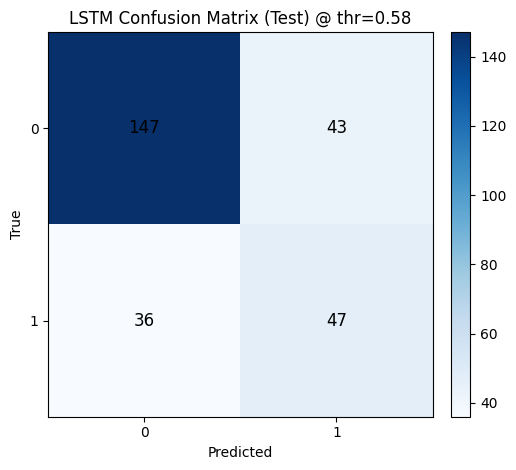

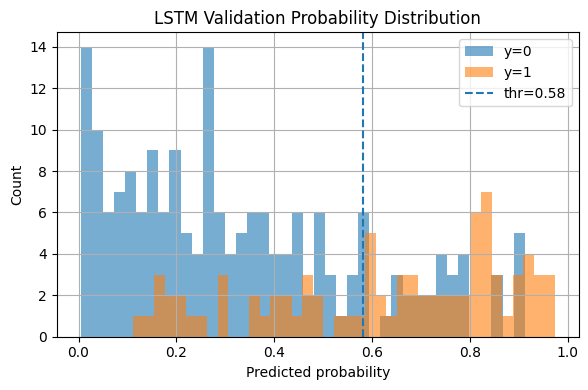

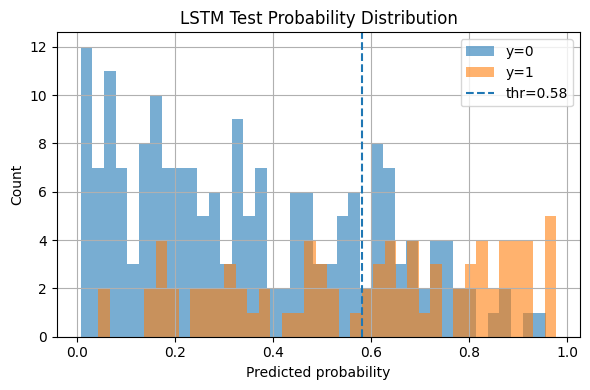

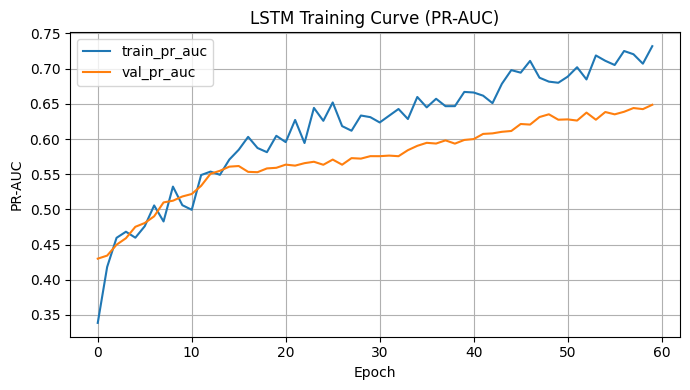

In [ ]:
# ============================================================
# LSTM — RANDOM SPLIT
# ============================================================

import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    average_precision_score, precision_recall_curve,
    roc_auc_score, roc_curve,
    f1_score, brier_score_loss
)

# -----------------------------
# 1) SETUP
# -----------------------------
drive.mount('/content/drive')

BASE_DIR   = "/content/drive/MyDrive/EarthEngine_ML_Data"
INPUT_FILE = os.path.join(BASE_DIR, "raw_merged_dataset.csv")

OUT_DIR    = os.path.join(BASE_DIR, "lstm_outputs_randomSplit_matchRF_GP_v1")
os.makedirs(OUT_DIR, exist_ok=True)

RANDOM_STATE = 42
SEQ_LEN = 14
RATIO = 1.09

REGION_COL = "Region_ID"
DATE_COL   = "Date"
DSWE_COL   = "DSWE_mean"

FEATURES = [
    "Precip_mm",
    "rain_sum_7", "rain_sum_15", "rain_sum_30",
    "rain_sum_60", "rain_sum_90",
    "rain_days_7",
]

# -----------------------------
# 2) LOAD + BASIC CLEANUP
# -----------------------------
print(f"Loading: {INPUT_FILE}")
df = pd.read_csv(INPUT_FILE)

df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
df = df.dropna(subset=[DATE_COL]).copy()

for c in [REGION_COL, DSWE_COL] + FEATURES:
    if c not in df.columns:
        raise ValueError(f"Missing column: {c}")

df[DSWE_COL] = pd.to_numeric(df[DSWE_COL], errors="coerce")
df = df.dropna(subset=[DSWE_COL]).copy()

# -----------------------------
# 3) LABEL (same as RF/GP)
# -----------------------------
df["Baseline_DSWE"] = df.groupby(REGION_COL)[DSWE_COL].transform("median")
df["Y"] = (df[DSWE_COL] > (df["Baseline_DSWE"] * RATIO)).astype(int)

print("\n--- Label distribution ---")
print(df["Y"].value_counts().sort_index())
print("Positive rate:", df["Y"].mean())
print("Share Baseline_DSWE==0:", (df["Baseline_DSWE"] == 0).mean())

# keep only needed cols and drop missing feature rows
need = [REGION_COL, DATE_COL, "Y"] + FEATURES
df = df[need].copy()
df[FEATURES] = df[FEATURES].apply(pd.to_numeric, errors="coerce")
df = df.dropna(subset=FEATURES + ["Y"]).copy()
df = df.sort_values([REGION_COL, DATE_COL]).reset_index(drop=True)

print("\nAfter dropna:", df.shape)
print("Date range:", df[DATE_COL].min(), "to", df[DATE_COL].max())

# -----------------------------
# 4) BUILD SEQUENCES (same logic as RF/GP)
# -----------------------------
def make_sequences(frame, features, label_col, date_col, region_col, seq_len):
    X_list, y_list, meta_list = [], [], []
    for rid, g in frame.groupby(region_col, sort=False):
        g = g.sort_values(date_col)
        Xv = g[features].to_numpy(dtype=np.float32)
        yv = g[label_col].to_numpy(dtype=np.int64)
        dv = g[date_col].to_numpy()

        if len(g) < seq_len:
            continue

        for i in range(seq_len - 1, len(g)):
            X_list.append(Xv[i - seq_len + 1 : i + 1])
            y_list.append(yv[i])
            meta_list.append({
                region_col: rid,
                date_col: pd.Timestamp(dv[i]),
                "Y": int(yv[i]),
            })

    X = np.stack(X_list) if X_list else np.empty((0, seq_len, len(features)), dtype=np.float32)
    y = np.array(y_list, dtype=np.int64)
    meta = pd.DataFrame(meta_list)
    return X, y, meta

X_seq, y_seq, meta_seq = make_sequences(df, FEATURES, "Y", DATE_COL, REGION_COL, SEQ_LEN)
print("\nSequence dataset:", X_seq.shape, y_seq.shape)
print("Seq positive rate:", y_seq.mean() if len(y_seq) else None)
if len(y_seq) == 0:
    raise ValueError("No sequences created. Lower SEQ_LEN or check Region_ID time series length.")

# -----------------------------
# 5) RANDOM SPLIT: Train / Val / Test (60/20/20), stratified
# -----------------------------
X_train, X_temp, y_train, y_temp, meta_train, meta_temp = train_test_split(
    X_seq, y_seq, meta_seq,
    test_size=0.40,
    stratify=y_seq,
    random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test, meta_val, meta_test = train_test_split(
    X_temp, y_temp, meta_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

print("\n--- Split sizes (random) ---")
print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("Train pos rate:", y_train.mean(), "Val pos rate:", y_val.mean(), "Test pos rate:", y_test.mean())

# -----------------------------
# 6) STANDARDIZE using TRAIN only
# -----------------------------
eps = 1e-6
mu = X_train.reshape(-1, X_train.shape[-1]).mean(axis=0)
sd = X_train.reshape(-1, X_train.shape[-1]).std(axis=0) + eps

def standardize(X, mu, sd):
    return (X - mu.reshape(1,1,-1)) / sd.reshape(1,1,-1)

X_train_s = standardize(X_train, mu, sd)
X_val_s   = standardize(X_val,   mu, sd)
X_test_s  = standardize(X_test,  mu, sd)

# -----------------------------
# 7) LSTM MODEL
# -----------------------------
tf.keras.utils.set_random_seed(RANDOM_STATE)

model = models.Sequential([
    layers.Input(shape=(SEQ_LEN, X_train_s.shape[-1])),
    layers.LSTM(64),
    layers.Dropout(0.25),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.20),
    layers.Dense(1, activation="sigmoid"),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.AUC(curve="PR", name="pr_auc"),
        tf.keras.metrics.AUC(curve="ROC", name="roc_auc")
    ]
)

# class weights (capped)
pos = int((y_train == 1).sum())
neg = int((y_train == 0).sum())
raw_w1 = neg / max(pos, 1)
w1 = float(min(raw_w1, 10.0))
class_weight = {0: 1.0, 1: w1}
print("\nClass weights (capped):", class_weight)

cb = [
    callbacks.EarlyStopping(monitor="val_pr_auc", mode="max", patience=8, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_pr_auc", mode="max", factor=0.5, patience=4, min_lr=1e-5),
]

history = model.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=60,
    batch_size=128,
    class_weight=class_weight,
    callbacks=cb,
    verbose=1
)

# -----------------------------
# 8) THRESHOLD SELECTION ON VAL ONLY (max F1)
# -----------------------------
val_proba = model.predict(X_val_s, batch_size=256).ravel()
p_v, r_v, thr_v = precision_recall_curve(y_val, val_proba)
f1s = (2 * p_v * r_v) / np.maximum(p_v + r_v, 1e-12)
best_idx = int(np.nanargmax(f1s))
best_thr = float(thr_v[best_idx - 1]) if best_idx > 0 else 0.5
best_f1_val = float(f1s[best_idx])

print(f"\nBest VAL threshold: {best_thr:.3f} (Val F1: {best_f1_val:.4f})")

# -----------------------------
# 9) TEST EVALUATION (fixed threshold from VAL)
# -----------------------------
test_proba = model.predict(X_test_s, batch_size=256).ravel()
test_pred  = (test_proba >= best_thr).astype(int)

pr_auc  = float(average_precision_score(y_test, test_proba))
roc_auc = float(roc_auc_score(y_test, test_proba))
brier   = float(brier_score_loss(y_test, test_proba))
f1      = float(f1_score(y_test, test_pred))

print("\n--- TEST metrics (VAL-threshold) ---")
print("PR-AUC:", pr_auc)
print("ROC-AUC:", roc_auc)
print("Brier:", brier)
print("F1:", f1)
print("\nConfusion matrix:\n", confusion_matrix(y_test, test_pred))
print("\nClassification report:\n", classification_report(y_test, test_pred, digits=4, zero_division=0))

# -----------------------------
# 10) SAVE outputs
# -----------------------------
# predictions CSV (TEST only)
pred_df = meta_test.copy().reset_index(drop=True)
pred_df["P_y1"] = test_proba
pred_df["Pred_y1"] = test_pred

pred_path = os.path.join(OUT_DIR, f"lstm_preds_randomSplit_ratio{RATIO}_seq{SEQ_LEN}.csv")
pred_df.to_csv(pred_path, index=False)
print("\nSaved TEST predictions to:", pred_path)

# model + scaler
model_path = os.path.join(OUT_DIR, f"lstm_randomSplit_ratio{RATIO}_seq{SEQ_LEN}.keras")
model.save(model_path)
np.save(os.path.join(OUT_DIR, f"scaler_mu_seq{SEQ_LEN}.npy"), mu)
np.save(os.path.join(OUT_DIR, f"scaler_sd_seq{SEQ_LEN}.npy"), sd)

# metrics JSON
with open(os.path.join(OUT_DIR, "metrics.json"), "w") as f:
    json.dump({
        "dswe_col": DSWE_COL,
        "ratio": RATIO,
        "best_val_threshold": best_thr,
        "val_best_f1": best_f1_val,
        "test_pr_auc": pr_auc,
        "test_roc_auc": roc_auc,
        "test_brier": brier,
        "test_f1": f1,
        "features": FEATURES,
        "seq_len": SEQ_LEN,
        "split_method": "stratified_random_60_20_20",
        "class_weight": class_weight,
    }, f, indent=2)

print("Saved model to:", model_path)
print(f"Saved all outputs to: {OUT_DIR}")

# -----------------------------
# 11) PLOTS (Comparable to RF/GP): PR, ROC, Confusion, Hist
# -----------------------------
# PR curve (TEST)
p_t, r_t, _ = precision_recall_curve(y_test, test_proba)
plt.figure(figsize=(6,5))
plt.plot(r_t, p_t)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"LSTM PR Curve (Test) | AP={pr_auc:.3f}")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "pr_curve_test.png"), dpi=200)
plt.show()

# ROC curve (TEST)
fpr, tpr, _ = roc_curve(y_test, test_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'k--', alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"LSTM ROC Curve (Test) | AUC={roc_auc:.3f}")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "roc_curve_test.png"), dpi=200)
plt.show()

# Confusion matrix (TEST @ VAL threshold)
cm = confusion_matrix(y_test, test_pred)
plt.figure(figsize=(5.5,4.8))
im = plt.imshow(cm, cmap="Blues")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks([0,1], ["0","1"])
plt.yticks([0,1], ["0","1"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"LSTM Confusion Matrix (Test) @ thr={best_thr:.2f}")

# annotate counts
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "confusion_matrix_test.png"), dpi=200)
plt.show()

# Probability histogram (VAL) + threshold line
plt.figure(figsize=(6,4))
plt.hist(val_proba[y_val==0], bins=40, alpha=0.6, label="y=0")
plt.hist(val_proba[y_val==1], bins=40, alpha=0.6, label="y=1")
plt.axvline(best_thr, linestyle="--", label=f"thr={best_thr:.2f}")
plt.xlabel("Predicted probability")
plt.ylabel("Count")
plt.title("LSTM Validation Probability Distribution")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "prob_hist_val.png"), dpi=200)
plt.show()

# Probability histogram (TEST) — optional, diagnostic
plt.figure(figsize=(6,4))
plt.hist(test_proba[y_test==0], bins=40, alpha=0.6, label="y=0")
plt.hist(test_proba[y_test==1], bins=40, alpha=0.6, label="y=1")
plt.axvline(best_thr, linestyle="--", label=f"thr={best_thr:.2f}")
plt.xlabel("Predicted probability")
plt.ylabel("Count")
plt.title("LSTM Test Probability Distribution")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "prob_hist_test.png"), dpi=200)
plt.show()

# Training curve (PR-AUC)
plt.figure(figsize=(7,4))
plt.plot(history.history.get("pr_auc", []), label="train_pr_auc")
plt.plot(history.history.get("val_pr_auc", []), label="val_pr_auc")
plt.xlabel("Epoch")
plt.ylabel("PR-AUC")
plt.title("LSTM Training Curve (PR-AUC)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "training_curve_pr_auc.png"), dpi=200)
plt.show()
